<a href="https://colab.research.google.com/github/yalexie1/volatility-surface-modeling/blob/main/vsm-project-notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Volatility Surface Modeling**

### Created by Yale Xie

**Important note about the project:** The goal I had when creating this project wasn't necessarily programming or mathematical proficiency (though I do feel that I've become a better coder doing this project). Instead, it was to help me better understand (enough to be able to explain) a core concept in quantitative finance without diving too deeply into the math. Also, when I made this, I was a high school senior who had taken an introductory vector calculus and linear algebra class and had some limited coding experience (mostly data science related). As such, I placed more emphasis on the explanations than the coding so that, ideally, anyone with a foundational understanding of options can read and understand what's going on.

## **Introduction**

The most famous equation in finance is almost undoubtedly that of the Black-Scholes model:

$\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + r S \frac{\partial V}{\partial S} - r V = 0$,

which when solved, leaves us with an explicit formula for the price of an option $V$ based on $S$ (the price of the underlying asset), $t$ (the time until the option's expiration), $r$ (the risk-free rate), and $\sigma$ (the asset's volatility).

However, despite this equation's status as a pillar of modern financial theory, there are some serious issues regarding the model's assumptions. One of these troublesome assumptions is that stock log-returns follow a log-normal distribution, implying that high loss events are statistically impossible.

In the real world, we've seen multiple occasions when this is not the case (1987, 2008, 2020). Because of this, traders bid up the price of certain options, past what the model suggests. In this project, we will approach this phenomenon through the lens of **implied volatility (IV)** and create a 3D visualization of strike price (we'll actually be using moneyness rather than strike price to "lock" the graph, explained later), time to maturity, and implied volatility. This modeling also allows us to value options that expire in times that don't have market data for that specific date.


## **Data**

For this project, we will be analyzing **S&P 500 (SPY) options**.

In [3]:
# libraries

import yfinance as yf
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

Here are the data collection steps necessary for this project:

1. Get the SPY data from yfinance
2. Collect the current spot price, which will be necessary when we calculate moneyness
3. Collect call option data (we're only looking at call options for this project*) for every available expiry date
4. Calculate time to maturity and convert to years

-------

\* Because the implied volatility of a call and a put at the same strike price should be identical to prevent arbitrage, we theoretically only need one set of option data to create the volatility surface plot. There is one caveat, though, which is that in-the-money options (options that have intrinsic value; think call option with strike price < spot price) are generally much less liquid than out-of-the-money options. Best practice would dicatate using OTM puts for strike prices < spot price and OTM calls for strike prices > spot price, but using only call options is simpler.

NOTE: The commented code generates the appropriate dataframe for the **current day's** SPY options. If you want to run this for your current day's options, uncomment the code and delete the uncommented code at the bottom. Right now, the following code block generates a dataframe with the SPY options from February 6th, 2026 (when I'm currently creating this project). The reason I've chosen to freeze my dataset is so that anyone can get the exact same charts and results I comment on later in this project.

In [4]:
# ticker = "SPY"
# spy = yf.Ticker(ticker)

# # get spot price (current market price of the asset)
# try:
#     spot_price = spy.history(period = '1d')['Close'].iloc[-1]
# except IndexError:
#     spot_price = spy.fast_info['last_price']

# options_data = []
# expirations = spy.options # list of expiration dates

# for expiry_date in expirations:

#     chain = spy.option_chain(expiry_date) # list of all available option contracts for expiry_date
#     calls = chain.calls # call option details (dataframe)

#     # time to maturity
#     exp_dt = datetime.strptime(expiry_date, "%Y-%m-%d") # exp_dt = expiry datetime
#     today = datetime.now()
#     days_to_expiry = (exp_dt - today).days

#     if days_to_expiry > 0: # exclude options expiring today or in the past
#         T = days_to_expiry / 365.0 # convert to time to maturity to years (important for formulas)
#         calls['T'] = T # add new years to expiry column
#         calls['Expiry'] = expiry_date # add new expiry column
#         options_data.append(calls)

# # combine options data into one dataframe
# df = pd.concat(options_data, ignore_index = True)
# df

ticker = "SPY"
df = pd.read_csv("spy_options_20260206.csv", parse_dates = ['Expiry'])
spot_price = df['strike'].iloc[0] / df['Moneyness'].iloc[0]
df

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,T,Expiry,Moneyness
0,SPY260220C00485000,2026-01-29 17:02:53+00:00,485.0,205.23,202.00,205.38,0.000000,0.000000,5.0,8,0.711917,True,REGULAR,USD,0.035616,2026-02-20,0.704476
1,SPY260220C00490000,2026-01-27 15:38:38+00:00,490.0,207.05,197.63,200.41,0.000000,0.000000,1.0,34,0.785158,True,REGULAR,USD,0.035616,2026-02-20,0.711739
2,SPY260220C00495000,2026-02-06 15:00:18+00:00,495.0,190.68,192.39,195.45,-9.060013,-4.535903,4.0,52,0.742190,True,REGULAR,USD,0.035616,2026-02-20,0.719001
3,SPY260220C00500000,2026-02-05 14:30:01+00:00,500.0,182.02,187.24,190.46,0.000000,0.000000,2.0,96,0.705569,True,REGULAR,USD,0.035616,2026-02-20,0.726264
4,SPY260220C00505000,2025-12-26 15:18:31+00:00,505.0,188.82,185.87,189.17,0.000000,0.000000,4.0,9,1.049443,True,REGULAR,USD,0.035616,2026-02-20,0.733527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2690,SPY281215C00870000,2026-02-05 19:49:57+00:00,870.0,30.02,33.21,33.50,0.000000,0.000000,19.0,21,0.189618,False,REGULAR,USD,2.854795,2028-12-15,1.263699
2691,SPY281215C00875000,2026-02-06 15:18:11+00:00,875.0,30.26,31.81,32.11,1.559999,5.435538,2.0,38,0.188420,False,REGULAR,USD,2.854795,2028-12-15,1.270962
2692,SPY281215C00880000,2026-02-06 16:24:20+00:00,880.0,30.24,30.26,30.52,2.930000,10.728672,5.0,29,0.186612,False,REGULAR,USD,2.854795,2028-12-15,1.278224
2693,SPY281215C00885000,2026-02-06 15:18:11+00:00,885.0,27.53,28.92,29.20,1.510000,5.803229,1.0,25,0.185402,False,REGULAR,USD,2.854795,2028-12-15,1.285487


Now, let's cull our data to ensure that we only keep relevant options.

1. If the bid price is 0 or the volume is 0, that means there is no demand for that option, so we remove it from the list.
2. If the moneyness is less than 0.7 (deeply ITM), the option's price is dominated by its intrinsic value (almost no volatility premium) so any tiny change in price will wildly shift the implied volatility. Conversely, if the moneyness is more than 1.3 (deeply OTM), the option's price is extremely low and any small change to the price would similarly overshift the implied volatility. These shifts are not necessarily indicative of actual investor fear and are more likely due to bid-ask spreads, which is why we have to filter for moneyness.
3. Options that expire very soon tend to behave chaotically because they are often used to price in specific events (e.g. if NVIDIA has an earnings report in 3 days).* Hence, we remove options with expiration times less than a week.

-----

\* It also has to do with vega ($\nu$) approaching 0:

$IV = \frac{\Delta S}{\nu}$, where $\nu ∝ \sqrt{t}$ and $t → 0$


In [5]:
# filter for liquidity
df = df[(df['bid'] > 0) & (df['volume'] > 0)]

# calculate moneyness
# 1 = ATM, <1 = ITM, >1 = OTM for call options
df['Moneyness'] = df['strike'] / spot_price

# filter for relevant zone
df = df[(0.7 < df['Moneyness']) & (df['Moneyness'] < 1.3)]

# remove super short-term options to maintain smoothness of plot
df = df[df['T'] > (7/365)]

# df.to_csv('spy_options_20260206.csv', index=False)

## **Plotting**

Before we plot, I will explain why we use moneyness on the x-axis instead of directly using strike price. Unlike strike price, moneyness will **maintain the relative location of the volatility curves**. If a stock's spot price moves, the ATM strike price (where the lowest volatility point should be) will follow it, which shifts the entire curve to a new location centered at the new ATM strike price if we plot by strike price. If we instead use moneyness, shifts in price will not affect the location of the volatility curve, since it's still centered at 1 (where ATM is always at).

In [6]:
fig = go.Figure(data = [go.Scatter3d(
    x = df['Moneyness'],
    y = df['T'],
    z = df['impliedVolatility'],
    mode = 'markers', # dots (markers)
    marker = dict(
        size = 3, # small dots so we can see the density
        color = df['impliedVolatility'], # color by implied volatility
        colorscale = 'Viridis',
        opacity = 0.8
    )
)])

# aesthetics
fig.update_layout(
    title = f"Implied Volatility Surface (Market Data)",
    scene = dict(
        xaxis_title = 'Moneyness (K/S)',
        yaxis_title = 'Time to Expiry (Years)',
        zaxis_title = 'Implied Volatility'
    ),
    margin = dict(l = 0, r = 0, b = 0, t = 30)
)

fig.show()

Let's interpret what we're seeing.

First, notice that the volatility curves for options with expiry times less than about half a year have a clear smile shape while the volatility curves for options with expiry times greater than a year are almost flat. This is because short-term options are highly sensitive to sudden price jumps while long-term options are dominated by the cumulative effect of many random price changes that tend to cancel out the skewness/kurtosis (Central Limit Theorem). Since Black-Scholes assumes a log-normal distribution of returns, this means that short-term options (whose underlying asset returns do not follow a log-normal distribution) exhibit the smile, while long-term options (whose underlying asset returns *do* generally follow a log-normal distribution) exhibit less of a smile.

Second, notice that ITM call options (low strike prices) tend to have higher implied volatilities than OTM call options (high strike prices). This is because ITM call options have the same implied volatility as OTM put options (if the strike price and expiration are the same)*, which are generally used to hedge against crashes. Since investors are generally more worried about huge losses than hopeful about large gains, they are willing to pay a higher premium for crash insurance. Hence, OTM put options (and ITM call options due to their mathematical linkage) are priced higher than high-strike options. This is also known as the implied volatility skew/smirk.

-----

\* This is true because of put-call parity, which relies on the no-arbitrage principle. Theoretically, the time value/premium (the price of the option minus its intrinsic value) of an ITM call must be equal to the time value of an OTM put because otherwise, arbitrageurs would buy the cheap option, short the expensive one, and lock in a risk-free profit. Since the premiums must be the same, so must their implied volatilities.

Finally, notice the small set of purple dots on the floor of the moneyness-time plane. All of these options have an implied volatility of around zero, are ITM, and have relatively short expiration times. They are mostly noise due to low liquidity for ITM options (this is why we filtered for moneyness > 0.7) and have zero implied volatility because their time premiums are very close to 0.

## **Stochastic Volatility Inspired (SVI) Model**

While the visualization we just created is helpful as a tool to observe the volatility smile, we would also like to be able to price options that have maturity dates within the gaps of the dots. To do this, we'll utilize Jim Gatheral's stochastic volatility inspired (SVI) model, which fits volatility smiles via five parameters ($a, b, \rho, m, \sigma$) to produce arbitrage-free volatility surfaces. Using this, we'll create a continuous visualization that allows us to infer the implied volatility of any option within a certain time frame, regardless of whether it has market data.

------

Some important equations:

- SVI variance equation: $w(k) = a + b\left( \rho (k - m) + \sqrt{(k - m)^2 + \sigma^2} \right)$
- SVI variance and implied volatility conversion: $w = T(IV^2)$
- Objective function (sum of squared errors): $\Sigma (w_{SVI}-w_{market})^2$

Let's first test the optimization function on one volatility smile (specifically, the one with an expiration time of around 6 months). To determine if the optimization went well, we'll plot the optimized curve against the raw market data to visualize the fit. If that works well, we'll then repeat the process for every expiration date and create a continuous surface plot with every fitted volatility curve.

Optimization for: 2026-07-31 00:00:00
Fitted parameters (a, b, rho, m, sigma): [-0.00396152  0.11566606 -0.51213966  0.08195233  0.12131236]


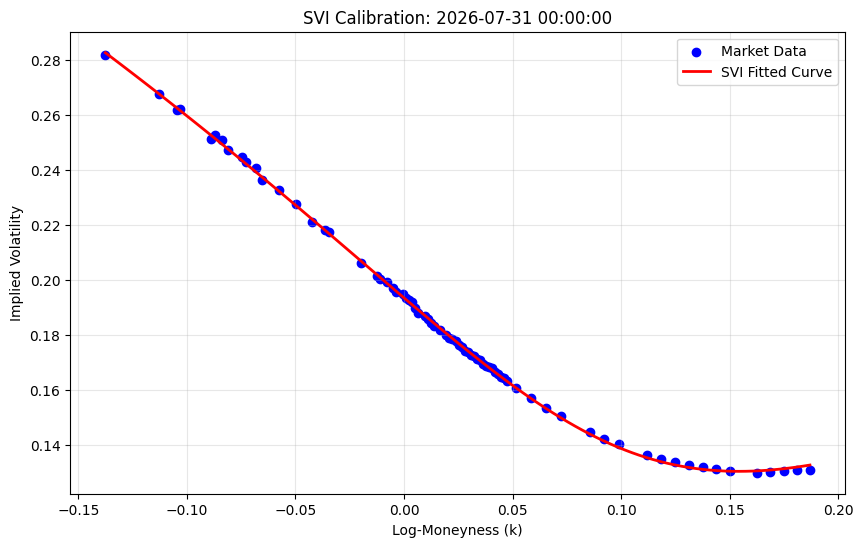

In [7]:
# calculates variance (w = IV^2 * T) based on the 5 parameters
def svi_raw(k, a, b, rho, m, sigma):
    # k = log-moneyness
    # a = base variance
    # b = slope
    # rho = skew
    # m = center
    # sigma = curvature
    return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma**2))

# data prep
target_t = 0.5 # cleanest smile is usually around 6 months out
closest_idx = (df['T'] - target_t).abs().idxmin() # find the specific expiry date closest to 6 months out
target_date = df.loc[closest_idx, 'Expiry']

print(f"Optimization for: {target_date}")

# filtering data for specific target date
slice_df = df[df['Expiry'] == target_date].copy()

# k (log-moneyness) = ln(strike/spot)
slice_df['k'] = np.log(slice_df['strike'] / spot_price)
# w (total variance) = IV^2 * Time; based on market data, NOT the model
slice_df['w_market'] = (slice_df['impliedVolatility'] ** 2) * slice_df['T'].iloc[0]

# objective function (returns error)
def objective_function(params, k_data, w_market): # fun(params, *args)
    a, b, rho, m, sigma = params

    # calculates w (total variance) based on the SVI model calculation
    w_model = svi_raw(k_data, a, b, rho, m, sigma)

    # sum of squared errors
    error = np.sum((w_model - w_market) ** 2)
    return error

# initial guesses
initial_guess = [0.04, 0.1, -0.5, 0.0, 0.1]

# constraints: sigma > 0, b > 0, |rho| < 1
bounds = ((None, None), (0, None), (-0.999, 0.999), (None, None), (0.001, None))

# optimization
result = minimize(
    objective_function,
    initial_guess,
    args = (slice_df['k'], slice_df['w_market']),
    bounds = bounds,
    method = 'L-BFGS-B'
)
print("Fitted parameters (a, b, rho, m, sigma):", result.x)

# visualization
k_smooth = np.linspace(slice_df['k'].min(), slice_df['k'].max(), 100) # x-axis
w_smooth = svi_raw(k_smooth, *result.x)
# IV = sqrt(w / T)
iv_smooth = np.sqrt(w_smooth / slice_df['T'].iloc[0]) # y-axis

plt.figure(figsize = (10, 6))
# market data
plt.scatter(slice_df['k'], slice_df['impliedVolatility'], label = 'Market Data', color = 'blue')
# SVI model fitted line
plt.plot(k_smooth, iv_smooth, label = 'SVI Fitted Curve', color = 'red', linewidth = 2)

plt.title(f"SVI Calibration: {target_date}")
plt.xlabel("Log-Moneyness (k)")
plt.ylabel("Implied Volatility")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

Seems like an excellent fit to me! I'll now comment on the fitted parameters:

- $a$ (base variance): -0.00396152. It's a little weird that $a$ is negative, but since it's only a tiny offset, total variance never actually drops below zero.
- $b$ (slope of the smile): 0.11566606. This is a realistic slope that makes sense.
- $m$ (center): 0.08195233. A little unexpected, since ATM (k = 0) options have the lowest implied volatility. A positive m indicates that OTM calls (k > 0) are even cheaper than ATM ones, likely an effect of the strong negative skew dragging the minimum point to the right.
- $\sigma$ (curvature): 0.12131236. Solid—indicates a soft smoothening of the smile.
- $\rho$ (skew): -0.51213966. This is probably the most informative parameter in this model, so let's unpack it carefully. $\rho$ measures how expensive investor fear is compared to investor hope. If $\rho = 0$, it costs the same to bet on a 10% rally (OTM call) as it does to hedge against a 10% crash (OTM put). At $\rho = -0.5$, this signifies that investors value OTM puts (and ITM calls due to put-call parity) more than their counterparts because of downside hedging. In other words, the market is putting a steeper price on fear/crash protection.

I think we're good to continue.

In [11]:
calibration_results = {} # store the optimized params for each date
unique_dates = df['Expiry'].unique()

print(f"Fitting {len(unique_dates)} volatilty curves")

for date in unique_dates:
    # get data for this slice
    slice_df = df[df['Expiry'] == date].copy()

    # skip the expiry date if there's not enough data (<5 points)
    if len(slice_df) < 5:
        continue

    # same as last code block
    slice_df['k'] = np.log(slice_df['strike'] / spot_price)
    slice_df['w_market'] = (slice_df['impliedVolatility'] ** 2) * slice_df['T'].iloc[0]


    # optimization
    result = minimize(
        objective_function,
        initial_guess,
        args = (slice_df['k'], slice_df['w_market']),
        bounds = bounds,
        method = 'L-BFGS-B'
    )
    if result.success:
        calibration_results[date] = result.x

print(f"Fitting complete.")
calibration_results

Fitting 24 volatilty curves
Fitting complete.


{Timestamp('2026-02-20 00:00:00'): array([-0.00448585,  0.05325305, -0.49451826, -0.03190852,  0.107687  ]),
 Timestamp('2026-02-27 00:00:00'): array([-0.24978226,  0.64952208, -0.75704368, -0.61590779,  0.59076215]),
 Timestamp('2026-03-06 00:00:00'): array([-0.00295643,  0.06049653, -0.49221577,  0.00372608,  0.07533482]),
 Timestamp('2026-03-13 00:00:00'): array([-5.59317368e-03,  7.34828792e-02, -4.99110557e-01, -1.42448154e-04,
         1.08388863e-01]),
 Timestamp('2026-03-20 00:00:00'): array([-0.0049837 ,  0.07936082, -0.49880868,  0.00614872,  0.09482203]),
 Timestamp('2026-03-31 00:00:00'): array([-0.49306965,  0.96174064, -0.76552335, -0.85502289,  0.80047332]),
 Timestamp('2026-04-17 00:00:00'): array([-0.02302622,  0.13767706, -0.5207145 , -0.03631496,  0.21989973]),
 Timestamp('2026-04-30 00:00:00'): array([-0.03162888,  0.16285821, -0.52604881, -0.03947868,  0.25306205]),
 Timestamp('2026-05-15 00:00:00'): array([-0.03291121,  0.17091642, -0.52751457, -0.02997187,  0.255

In [12]:
surface_data = [] # we will convert this into a dataframe later; right now, it will be a list of dicts

# for each expiration date, generate smooth points across the moneyness range
for date, params in calibration_results.items():

    # time to expiry
    T = df[df['Expiry'] == date]['T'].iloc[0]

    # k_range is a 1D array of equally spaced log-moneyness values
    k_range = np.linspace(np.log(0.7), np.log(1.3), 100)

    # calculate SVI variance
    w_model = svi_raw(k_range, *params)

    # convert to IV
    iv_model = np.sqrt(w_model / T)

    # convert log_moneyness back to moneyness
    moneyness_axis = np.exp(k_range)

    # store rows for plotting
    for m, iv in zip(moneyness_axis, iv_model):
        surface_data.append({
            'Expiry': date,
            'T': T,
            'Moneyness': m,
            'Implied Volatility': iv
        })

df_surface = pd.DataFrame(surface_data)

df_surface

,Expiry,T,Moneyness,Implied Volatility
0,2026-02-20,0.035616,0.700000,0.791053
1,2026-02-20,0.035616,0.704391,0.782481
2,2026-02-20,0.035616,0.708809,0.773825
3,2026-02-20,0.035616,0.713255,0.765083
4,2026-02-20,0.035616,0.717729,0.756254
...,...,...,...,...
2395,2028-12-15,2.854795,1.267888,0.188336
2396,2028-12-15,2.854795,1.275841,0.187047
2397,2028-12-15,2.854795,1.283844,0.185888
2398,2028-12-15,2.854795,1.291897,0.184867


We're ready to plot the continuous surface!

In [13]:
# first, we need to restructure our dataframe into a 2D matrix
# we do this using pandas' .pivot() function
# index (y-axis) = time to expiry
# columns (x-axis) = moneyness
# values (z-axis) = implied volatility
pivot_df = df_surface.pivot(index = 'T', columns = 'Moneyness', values = 'Implied Volatility')

# extract values
X_grid = pivot_df.columns.values  # moneyness
Y_grid = pivot_df.index.values    # time to expiry
Z_grid = pivot_df.values          # implied volatility

# plotting
fig = go.Figure(data=[go.Surface(
    x = X_grid,
    y = Y_grid,
    z = Z_grid,
    opacity = 0.9,
    colorscale = 'Viridis',
    contours_z = dict(
        show = True,
        usecolormap = True,
        highlightcolor = "limegreen",
        project_z = True # contour lines enabled
    )
)])

fig.update_layout(
    title = 'Continuous SVI Volatility Surface',
    scene = dict(
        xaxis_title = 'Moneyness (K/S)',
        yaxis_title = 'Time to Expiry (Years)',
        zaxis_title = 'Implied Volatility',
    ),
    width = 900, height = 700,
    margin = dict(l = 0, r = 0, b = 0, t = 50)
)

fig.show()

## **Discussion**

So what have we learned from this visualization?

1. The market puts a tax on fear, but only in the short term. In the plot, we can observe a large left spike in implied volatility when time to maturity is below half a year, but for options that have higher times to maturity, that surcharge is mostly absent. This phenomenon is also known as **jump risk decay**.

2. Over long periods, the distribution of returns tends to behave more log-normally. This is seen by the lack of a distinct smile for options with high times to expiry, instead being closer to a flat curve (which is what Black-Scholes would assume).

3. Implied volatility (a measure of uncertainty) increases over time for ATM options. This means that ATM options with long expiry times are worth more than those with short expiry times, which should be somewhat intuitive because uncertainty (range of prices it could be) builds over time. This behavior is also known as **contango**, a situation in which the future price is higher than today's.